In [141]:
import yfinance as yf

In [ ]:
#analyze call options from AAPL

ticker = "AAPL"

stock = yf.Ticker(ticker)

print(stock.options)

('2025-10-31', '2025-11-07', '2025-11-14', '2025-11-21', '2025-11-28', '2025-12-05', '2025-12-19', '2026-01-16', '2026-02-20', '2026-03-20', '2026-04-17', '2026-06-18', '2026-09-18', '2026-12-18', '2027-01-15', '2027-06-17', '2027-12-17', '2028-01-21')


In [143]:
expiry = "2026-06-18"

opt_chain = stock.option_chain(expiry)

calls = opt_chain.calls


In [144]:
import datetime as dt

today = dt.datetime.now()
expiry_date = dt.datetime.strptime(expiry, "%Y-%m-%d")
days_to_expiry = (expiry_date - today).days

S = stock.history(period="1d")['Close'].iloc[-1]  # last close price
risk_free_rate = 0.0423  # or pull from FRED / manually set

# Prepare dataframe
calls['price'] = S
calls['remaining'] = days_to_expiry

In [145]:
import numpy as np
import scipy.stats as si

def black_scholes_call(S, X, T, r, sigma):
    if sigma == 0 or T == 0:
        return 0
    d1 = (np.log(S / X) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = (S * si.norm.cdf(d1, 0.0, 1.0)
                  - X * np.exp(-r * T) * si.norm.cdf(d2, 0.0, 1.0))
    return call_price


# Filter and compute
df_filtered = calls[calls['impliedVolatility'] <= 3].copy()

df_filtered['Predicted Call Price'] = df_filtered.apply(
    lambda row: black_scholes_call(
        S=row['price'],
        X=row['strike'],
        T=row['remaining'] / 365,
        r=risk_free_rate,
        sigma=row['impliedVolatility']
    ),
    axis=1
)

# Clean and save
df_filtered_clean = df_filtered.replace([np.inf, -np.inf], np.nan).dropna(
    subset=['bid', 'ask', 'Predicted Call Price']
)
output_csv_path_new_predictions = 'C:/Users/hilto/boston_uni/ds/output_files/predicted_call_prices_from_yahoo.csv'
df_filtered_clean.to_csv(output_csv_path_new_predictions, index=False)

print("✅ Saved:", output_csv_path_new_predictions)


✅ Saved: C:/Users/hilto/boston_uni/ds/output_files/predicted_call_prices_from_yahoo.csv


In [146]:
from sklearn.metrics import r2_score

r2 = r2_score(df_filtered_clean['lastPrice'], df_filtered_clean['Predicted Call Price'])
print(f"R² of Black-Scholes vs. Yahoo last price: {r2:.3f}")

R² of Black-Scholes vs. Yahoo last price: 0.941


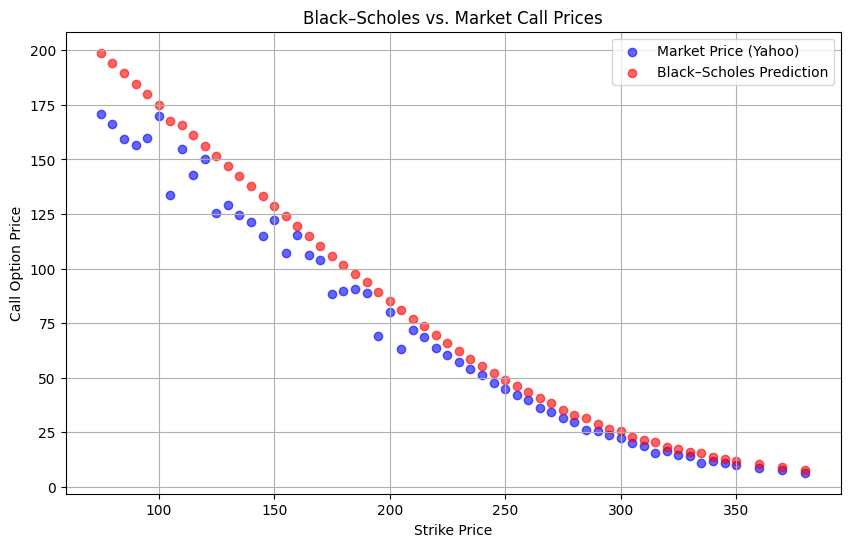

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(df_filtered_clean['strike'], df_filtered_clean['lastPrice'], 
            color='blue', label='Market Price (Yahoo)', alpha=0.6)
plt.scatter(df_filtered_clean['strike'], df_filtered_clean['Predicted Call Price'], 
            color='red', label='Black–Scholes Prediction', alpha=0.6)

plt.title("Black–Scholes vs. Market Call Prices")
plt.xlabel("Strike Price")
plt.ylabel("Call Option Price")
plt.legend()
plt.grid(True) 
plt.show()

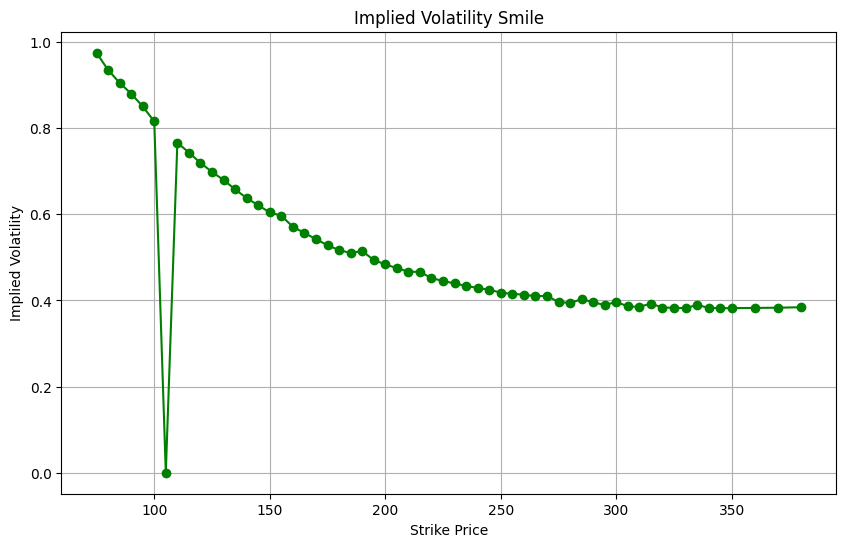

In [148]:
plt.figure(figsize=(10,6))
plt.plot(df_filtered_clean['strike'], df_filtered_clean['impliedVolatility'], 'o-', color='green')
plt.title("Implied Volatility Smile")
plt.xlabel("Strike Price")
plt.ylabel("Implied Volatility")
plt.grid(True)
plt.show()

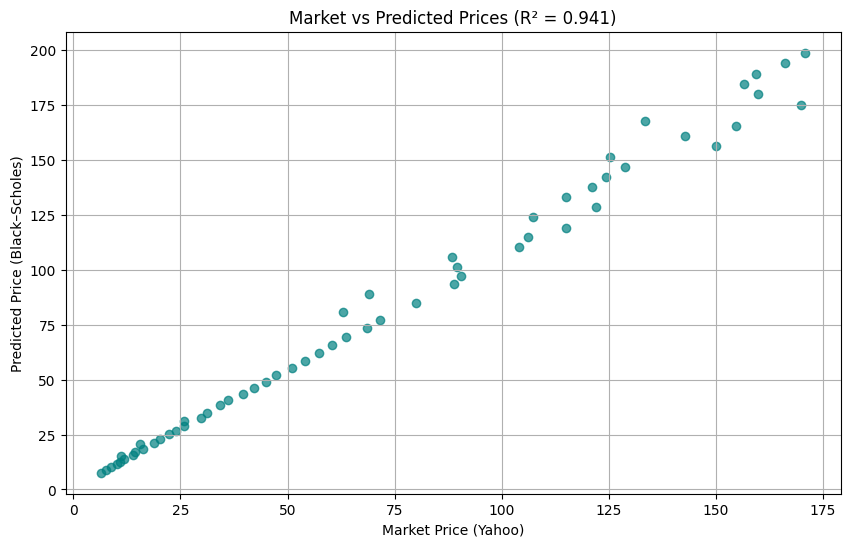

In [150]:
from sklearn.metrics import r2_score
r2 = r2_score(df_filtered_clean['lastPrice'], df_filtered_clean['Predicted Call Price'])

plt.figure(figsize=(10,6))
plt.scatter(df_filtered_clean['lastPrice'], df_filtered_clean['Predicted Call Price'], color='teal', alpha=0.7)
plt.title(f"Market vs Predicted Prices (R² = {r2:.3f})")
plt.xlabel("Market Price (Yahoo)")
plt.ylabel("Predicted Price (Black–Scholes)")
plt.grid(True)
plt.show()

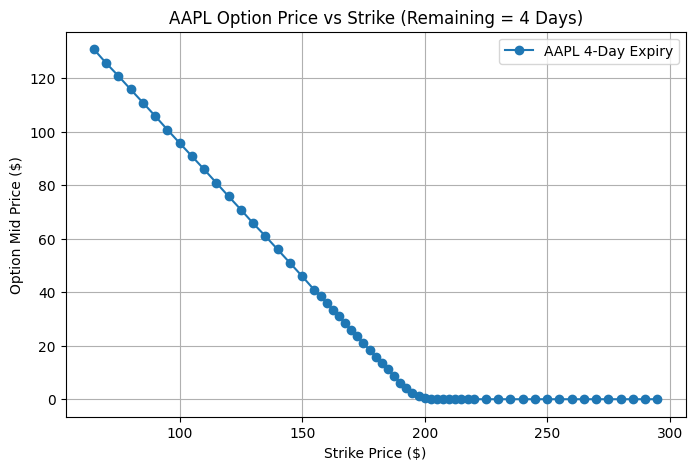

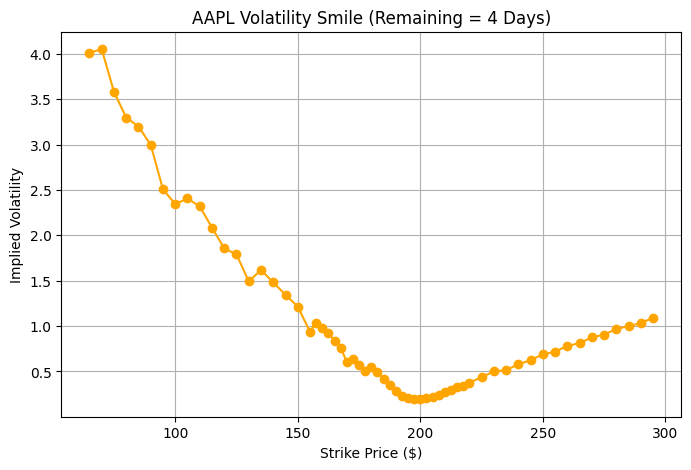

In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# --- Load ---
df = pd.read_csv("calls_dataset.csv")

# --- Extract base ticker (e.g., AAPL) from contract symbol ---
df["ticker"] = df["contractSymbol"].apply(lambda x: re.match(r"([A-Z]+)", x).group(1))

# --- Filter for one ticker ---
ticker = "AAPL"
subset = df[df["ticker"] == ticker]

# --- Pick 1 timeline (e.g., 4 days remaining) ---
timeline = 4
subset = subset[subset["remaining"] == timeline].copy()

# --- Compute mid price ---
subset["mid"] = (subset["bid"] + subset["ask"]) / 2

# --- Sort by strike ---
subset = subset.sort_values(by="strike")


plt.figure(figsize=(8,5))
plt.plot(subset["strike"], subset["mid"], 'o-', label=f"{ticker} {timeline}-Day Expiry")
plt.title(f"{ticker} Option Price vs Strike (Remaining = {timeline} Days)")
plt.xlabel("Strike Price ($)")
plt.ylabel("Option Mid Price ($)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(subset["strike"], subset["impliedVolatility"], 'o-', color="orange")
plt.title(f"{ticker} Volatility Smile (Remaining = {timeline} Days)")
plt.xlabel("Strike Price ($)")
plt.ylabel("Implied Volatility")
plt.grid(True)
plt.show()

# plt.figure(figsize=(8,5))
# plt.plot(subset["moneyness"], subset["mid"], marker='o', label="Mid Option Price")
# plt.title("Option Price vs Strike Price (AAPL Calls)")
# plt.xlabel("Strike Price ($)")
# plt.ylabel("Option Price ($)")
# plt.grid(True)
# plt.legend()
# plt.show()

In [152]:
import pandas as pd
import numpy as np
import scipy.stats as si

def black_scholes_call(S, X, T, r, sigma):
    if sigma == 0 or T == 0:
        return 0
    d1 = (np.log(S / X) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = (S * si.norm.cdf(d1, 0.0, 1.0) - X * np.exp(-r * T) * si.norm.cdf(d2, 0.0, 1.0))
    return call_price

def calculate_correlations(csv_file_path):
    df = pd.read_csv(csv_file_path)
    risk_free_rate = 0.0423

    # Fetch predicted call prices.
    df['Predicted Call Price'] = df.apply(
        lambda row: black_scholes_call(row['price'], row['strike'], row['remaining'] / 365, risk_free_rate, row['impliedVolatility']),
        axis=1
    )

    # Calculate correlations.
    correlation_maturity_predicted_price = df['remaining'].corr(df['Predicted Call Price'])
    correlation_volatility_predicted_price = df['impliedVolatility'].corr(df['Predicted Call Price'])

    return correlation_maturity_predicted_price, correlation_volatility_predicted_price

csv_file_path = 'predicted_call_prices.csv'
correlations = calculate_correlations(csv_file_path)
print("Correlation between Time to Maturity and Predicted Call Price:", correlations[0])
print("Correlation between Implied Volatility and Predicted Call Price:", correlations[1])

Correlation between Time to Maturity and Predicted Call Price: 0.1221465209560491
Correlation between Implied Volatility and Predicted Call Price: 0.04684599964945889


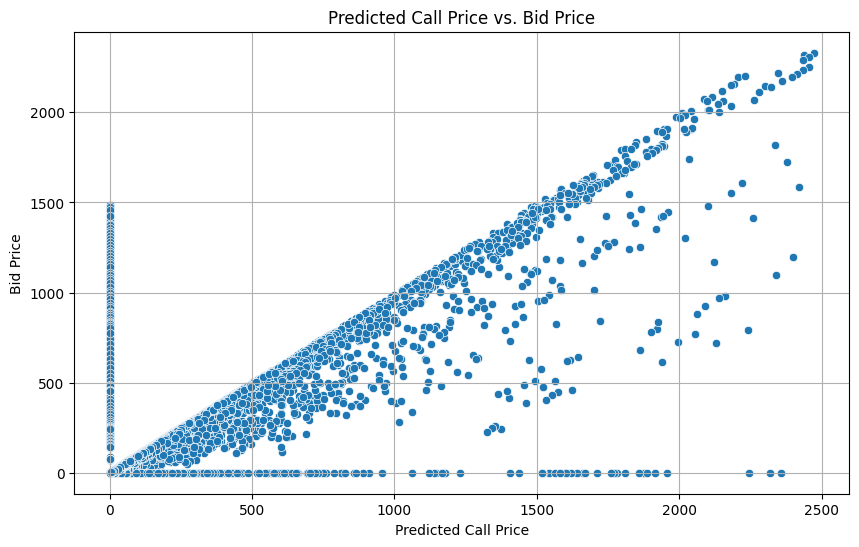

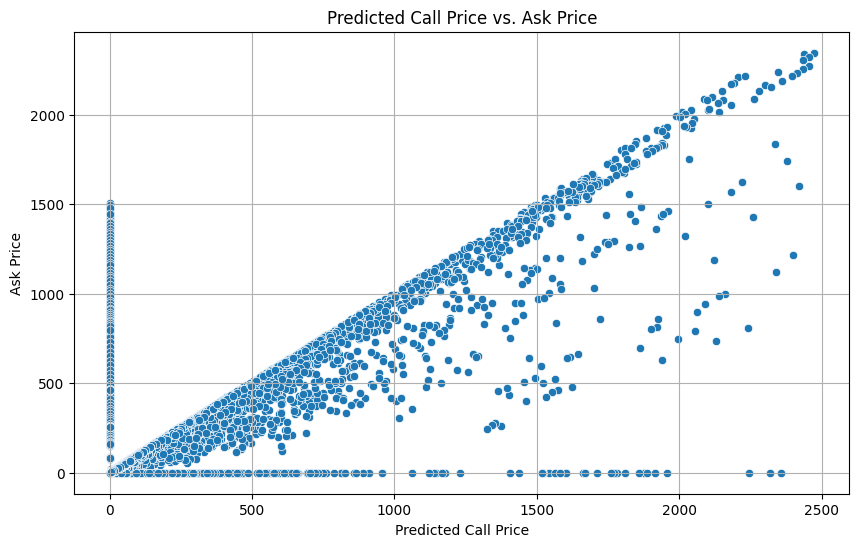

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('predicted_call_prices.csv')

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Predicted Call Price'], y=df['bid'])
plt.title('Predicted Call Price vs. Bid Price')
plt.xlabel('Predicted Call Price')
plt.ylabel('Bid Price')
plt.grid(True)
plt.savefig('scatter_predicted_vs_bid.png')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Predicted Call Price'], y=df['ask'])
plt.title('Predicted Call Price vs. Ask Price')
plt.xlabel('Predicted Call Price')
plt.ylabel('Ask Price')
plt.grid(True)
plt.savefig('scatter_predicted_vs_ask.png')
plt.show()

In [174]:
# r2_values_bid = []
# r2_values_ask = []
# volatility_frequencies = []

# for label in volatility_labels:
#     subset = options_data[options_data['Volatility_Range'] == label]
#     if not subset.empty:
#         r2_bid = r2_score(subset['bid'], subset['Predicted Call Price'])
#         r2_ask = r2_score(subset['ask'], subset['Predicted Call Price'])
#     else:
#         r2_bid = np.nan  # Use NaN to indicate no data
#         r2_ask = np.nan

#     frequency = len(subset)
#     r2_values_bid.append(r2_bid)
#     r2_values_ask.append(r2_ask)
#     volatility_frequencies.append(frequency)

# plt.figure(figsize=(12, 6))
# plt.subplot(1, 2, 1)
# plt.bar(volatility_labels, volatility_frequencies, color='skyblue')
# plt.title('Frequency of Different Volatility Ranges')
# plt.xlabel('Volatility Range')
# plt.ylabel('Frequency')

# plt.subplot(1, 2, 2)
# bar_width = 0.35
# index = np.arange(len(volatility_labels))

# bar1 = plt.bar(index, r2_values_bid, bar_width, label='R² vs Bid', color='orange')
# bar2 = plt.bar(index + bar_width, r2_values_ask, bar_width, label='R² vs Ask', color='green')

# plt.title('R² Values for Different Volatility Ranges')
# plt.xlabel('Volatility Range')
# plt.ylabel('R² Value')
# plt.xticks(index + bar_width / 2, volatility_labels)
# plt.legend()

# plt.tight_layout()
# plt.show()

In [129]:
#Binomial Opitons Pricing Model

In [155]:
import numpy as np

def binomial_call_price(S, K, T, r, sigma, n=100):
    """
    Compute the European call option price using the Cox-Ross-Rubinstein model.
    """
    dt = T / n
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    
    # Terminal prices
    ST = S * d**np.arange(n, -1, -1) * u**np.arange(0, n+1)
    payoff = np.maximum(ST - K, 0)
    
    # Backward induction
    for i in range(n-1, -1, -1):
        payoff = np.exp(-r * dt) * (p * payoff[1:] + (1 - p) * payoff[:-1])
    
    return payoff[0]


In [163]:
import pandas as pd

df = pd.read_csv("calls_dataset.csv")

r = 0.05  # risk-free rate
n_steps = 100

def compute_binomial(row):
    S = row["price"]
    K = row["strike"]
    sigma = row["impliedVolatility"]
    T = row["remaining"] / 365  # convert to years
    
    if T <= 0 or sigma <= 0:
        return np.nan
    return binomial_call_price(S, K, T, r, sigma, n_steps)

df["Binomial_Call"] = df.apply(compute_binomial, axis=1)

df["Binomial_Call"]


0        130.804499
1        125.865244
2        120.822703
3        115.813289
4        110.842121
            ...    
73863     29.434242
73864     17.771587
73865     14.285932
73866     10.076337
73867      6.755257
Name: Binomial_Call, Length: 73868, dtype: float64

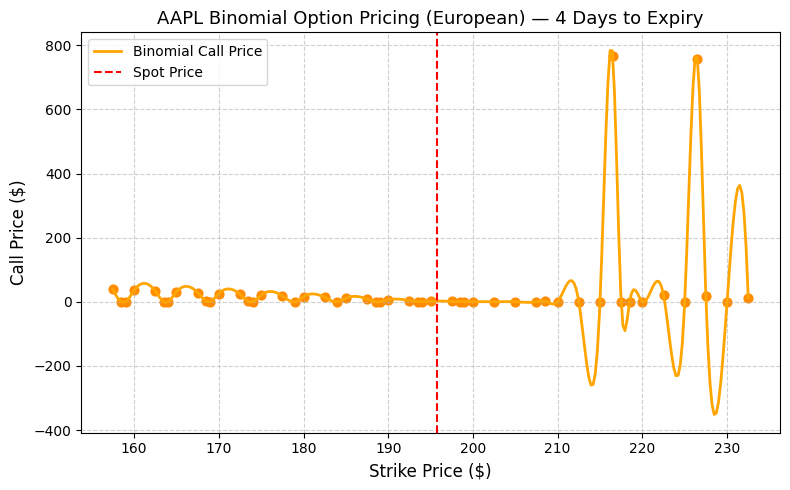

In [167]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline



spot_price = df["price"].iloc[0]
filtered = df[(df["remaining"] == 4) & 
              (df["strike"].between(0.8*spot_price, 1.2*spot_price))]

filtered = filtered.drop_duplicates(subset=["strike"])


filtered = filtered.replace([np.inf, -np.inf], np.nan).dropna(subset=["Binomial_Call"])
filtered = filtered.sort_values(by="strike")

x = filtered["strike"].values
y = filtered["Binomial_Call"].values

x_smooth = np.linspace(x.min(), x.max(), 300)
y_smooth = make_interp_spline(x, y)(x_smooth)

plt.figure(figsize=(8,5))
plt.plot(x_smooth, y_smooth, color="orange", linewidth=2, label="Binomial Call Price")
plt.scatter(x, y, color="darkorange", s=40)
plt.axvline(spot_price, color="red", linestyle="--", label="Spot Price")
plt.xlabel("Strike Price ($)", fontsize=12)
plt.ylabel("Call Price ($)", fontsize=12)
plt.title("AAPL Binomial Option Pricing (European) — 4 Days to Expiry", fontsize=13)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()



In [161]:
df = df.to_csv("BOPM.csv")